<a href="https://colab.research.google.com/github/EJBass2003/CIS-3902-AI-ML-Eric-Bass/blob/main/random_forest_crime_assignment_EB(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14142893,JK188594,2026-03-21T00:00:00.000,020XX W COULTER ST,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,False,True,...,25,31.0,26,1163045.0,1888229.0,2026,2026-03-28T16:03:10.000,41.848945,-87.677097,"\n, \n(41.848945486, -87.677097255)"
1,14144446,JK190482,2026-03-21T00:00:00.000,065XX W SCHOOL ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,38,17.0,14,1132015.0,1921224.0,2026,2026-03-28T16:03:10.000,41.940082,-87.790215,"\n, \n(41.940082468, -87.790215495)"
2,14145209,JK191649,2026-03-21T00:00:00.000,002XX N JEFFERSON ST,0710,THEFT,THEFT FROM MOTOR VEHICLE,STREET,False,False,...,34,28.0,06,1172286.0,1901798.0,2026,2026-03-28T16:03:10.000,41.885981,-87.642781,"\n, \n(41.885981015, -87.642781484)"
3,14143426,JK189251,2026-03-21T00:00:00.000,005XX E 32ND ST,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,4,35.0,08A,1180539.0,1883677.0,2026,2026-03-28T16:03:10.000,41.836070,-87.613033,"\n, \n(41.836069707, -87.613033345)"
4,14142897,JK188712,2026-03-21T00:00:00.000,054XX S KENNETH AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,23,62.0,07,1147620.0,1868175.0,2026,2026-03-28T16:03:10.000,41.794224,-87.734222,"\n, \n(41.794223942, -87.734222119)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent? **Each row represents a single, specific reported crime incident in the city of Chicago.**
2. Which variables look potentially useful for prediction? **Variables that describe the nature and context of the event are the most useful. This includes primary_type (the type of crime), location_description (where it occurred, like a street or apartment), domestic (if it was a domestic incident), and geographic indicators like district, ward, latitude, and longitude**
3. Which variable appears to be the target for this assignment? **The arrest variable (a boolean True/False value) is the target variable, as the goal of the notebook is to predict whether a reported incident resulted in an arrest.**


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49751 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        49999 non-null  float64
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [3]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49751,50000,50000,...,50000.000000,49999.000000,50000,4.993200e+04,4.993200e+04,50000.00000,50000,49932.000000,49932.000000,49932
unique,NaN,49997,27281,16945,284,28,266,107,2,2,...,NaN,NaN,24,NaN,NaN,NaN,75,NaN,NaN,33687
top,NaN,JK174465,2026-01-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.754592961, -87.741528537)"
freq,NaN,2,49,139,4139,11012,6174,13427,42129,40287,...,NaN,NaN,12305,NaN,NaN,NaN,40518,NaN,NaN,73
mean,1.407843e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.799260,36.325367,NaN,1.165783e+06,1.887056e+06,2025.88860,NaN,41.845655,-87.667124,NaN
std,6.003802e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.934754,21.339844,NaN,1.620840e+04,3.119420e+04,0.31463,NaN,0.085784,0.059018,NaN
min,2.898500e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814333e+06,2025.00000,NaN,41.645288,-87.927365,NaN
25%,1.408366e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.154589e+06,1.860364e+06,2026.00000,NaN,41.772314,-87.707778,NaN
50%,1.410452e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.167622e+06,1.893058e+06,2026.00000,NaN,41.862218,-87.660144,NaN
75%,1.412431e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176977e+06,1.909814e+06,2026.00000,NaN,41.908348,-87.626045,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [4]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,CRIMINAL TRESPASS,False,True,10,41.848945,-87.677097
1,CRIMINAL DAMAGE,False,False,16,41.940082,-87.790215
2,THEFT,False,False,12,41.885981,-87.642781
3,ASSAULT,False,True,2,41.836070,-87.613033
4,MOTOR VEHICLE THEFT,False,False,8,41.794224,-87.734222


### Short Response
Why might missing values cause problems in machine learning and mapping? **Mapping libraries will fail or throw errors if they try to plot coordinates that don't exist (NaN values in latitude or longitude). Similarly, standard machine learning algorithms like Random Forest require complete numerical or boolean data to perform mathematical splits.**


## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [5]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas? **The points heavily cluster in certain areas. Crime and policing do not happen uniformly across a city. They are concentrated in specific neighborhoods, commercial districts, or hotspots.**
2. Do you see any visible differences between arrest and non-arrest locations? **Non-arrest locations (False, the blue markers) are the vast majority and are spread widely across the city. Arrest locations (True, the red markers) are noticeably less frequent and tend to cluster tightly in specific geographic pockets or districts.**
3. If location turns out to be important later, does this map help explain why? **Yes, the map provides visual proof of spatial clustering. Because arrests are heavily concentrated in specific geographic areas rather than being randomly distributed among all reported crimes, the algorithm will naturally learn that a specific location (latitude/longitude) is a strong indicator of an arrest occurring.**


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


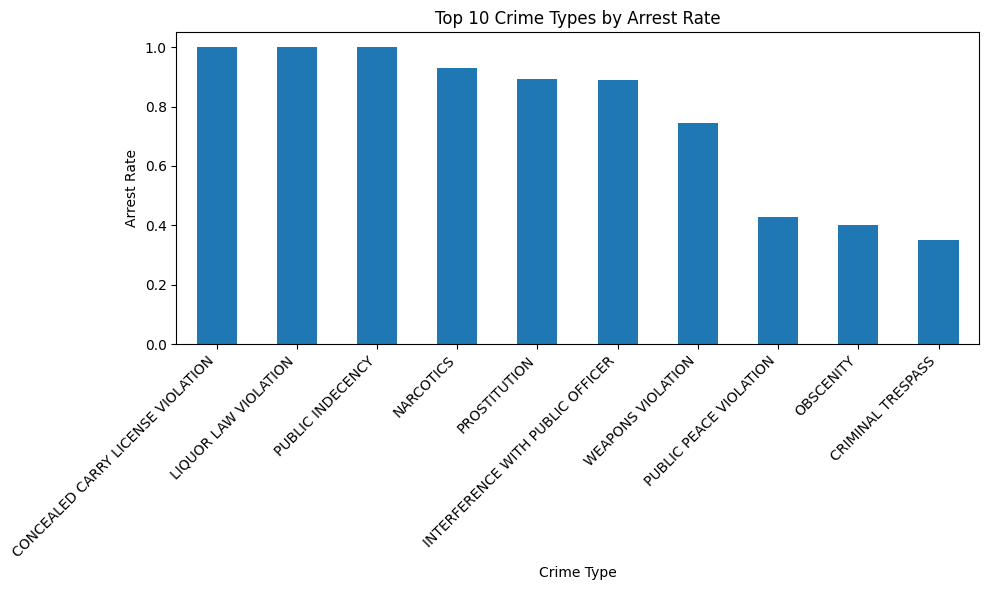

In [6]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you?
**NARCOTICS, WEAPONS VIOLATION, and INTERFERENCE WITH PUBLIC OFFICER are the most likely to lead to an arrest. It isn't too surprising. These are typically "police-discovered" or proactive crimes. A police officer usually discovers the drugs or weapons during a stop, meaning the discovery of the crime and the arrest happen at the exact same time.**

## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [7]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,True,41.848945,-87.677097,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,41.940082,-87.790215,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,41.885981,-87.642781,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,41.836070,-87.613033,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,41.794224,-87.734222,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [8]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8673275257835186

Confusion Matrix:
[[7899  462]
 [ 863  763]]

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.94      0.92      8361
        True       0.62      0.47      0.54      1626

    accuracy                           0.87      9987
   macro avg       0.76      0.71      0.73      9987
weighted avg       0.86      0.87      0.86      9987



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.322554
longitude,0.319688
primary_type_NARCOTICS,0.144124
primary_type_WEAPONS VIOLATION,0.059980
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.020426
domestic,0.011310
primary_type_CRIMINAL DAMAGE,0.010328
primary_type_CRIMINAL TRESPASS,0.010112
primary_type_MOTOR VEHICLE THEFT,0.008324
primary_type_BATTERY,0.007893


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


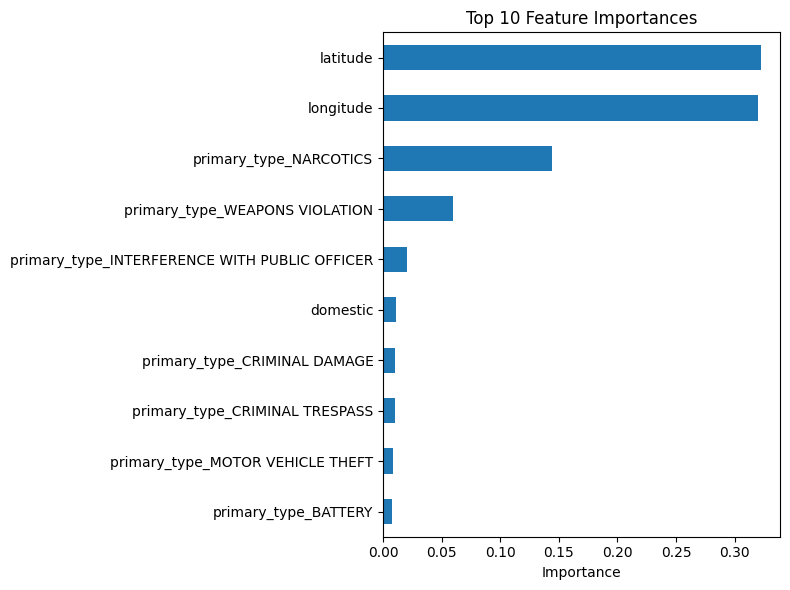

In [13]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most? **The features that matter the most are latitude (0.325) and longitude (0.319). Combined, they are vastly more important than any other single variable.**
2. Does the model seem to rely more on **location** or **crime type**? **The model heavily relies on location. Latitude and longitude together make up over 64% of the model's decision-making weight.**
3. What does that suggest about arrest outcomes in the dataset? **This suggests that where an incident happens is a stronger predictor of whether someone will be arrested than the actual type of crime committed.**


## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86943026 0.86842896 0.87682756 0.87141999 0.86481074]
Average cross-validation score: 0.8701834997152618


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well? **Based on the classification report in Step 10, the model is very good at predicting when an arrest will not be made (the False class). It correctly identifies 95% of the non-arrests (0.95 recall) and has a high precision (0.90) for that category.**
2. What are its limitations? **The model struggles significantly to predict when an arrest will occur. Its recall for the True class is only 0.45, meaning it misses more than half of the actual arrests.**
3. What does feature importance suggest about the strongest predictors of arrest? **It reinforces that geography is the strongest predictor of an arrest. It implies that police presence, neighborhood dynamics, or geographic resource allocation heavily dictate whether a reported incident results in someone being taken into custody.**
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself? **Crime data is often confused with policing data. A model predicting "arrests" is essentially predicting police behavior and systemic outcomes, not the objective occurrence of a crime. For example, high arrest rates for narcotics in a specific neighborhood don't necessarily mean drug use is exclusively high there. It often means police are actively patrolling and enforcing drug laws in that specific neighborhood.**
5. Should a model like this be used in real-world policing decisions? Why or why not? **No, a model like this should not be used to allocate police resources or make real-world policing decisions. Because the model relies so heavily on location, using it for predictive policing would create a dangerous "runaway feedback loop."**
